In [1]:
# CELL 1: Setup, Imports & Data Loading

# --- Core Libraries & Setup ---
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from scipy.stats import chi2_contingency
from tab_transformer_pytorch import TabTransformer
from pathlib import Path
OUT_DIR = Path("output")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
import random
random.seed(SEED); np.random.seed(SEED)
try:
    torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
except Exception:
    pass

# --- Global Settings ---
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (10, 8)})

# 1. Load the new master dataframe
master_df = pd.read_csv('GSE95640_master_dataframe.csv', index_col=0)

# 2. Define the new target variable 'y'
target_map = {
    'CID1 is for the baseline without LCD': 0,
    'CID2 is after 8 weeks of LCD': 1
}
y = master_df['time'].map(target_map)

# 3. Define the new feature matrix 'X'
X = master_df.drop(columns=['time'])

# 4. (New Step) Clean data before CV: Remove samples with missing target
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

print(f"Data for GSE95640 loaded successfully. Found {len(X)} samples.")

Data for GSE95640 loaded successfully. Found 382 samples.


In [2]:
# CELL 2: Define All Helper Functions

# This function is heavily simplified to only handle 'age' and 'gender'.
def process_fold_features(X_train, y_train, X_test):
    """
    Encapsulates all feature engineering for a single fold (GSE95640 version).
    """
    
    # --- 1. Process Categorical (Clinical) Features ---
    
    # 1a. Define the known columns
    known_cat_cols = ['age', 'gender', 'tissue']
    cat_cols = [col for col in known_cat_cols if col in X_train.columns]
    
    if not cat_cols:
        print("  No clinical features found.")
        X_train_cat = pd.DataFrame(index=X_train.index)
        X_test_cat = pd.DataFrame(index=X_test.index)
        selected_categorical_features = []
    
    else:
        X_train_cat = X_train[cat_cols].copy()
        X_test_cat = X_test[cat_cols].copy()

        # 1b. Remove 'tissue' as it is constant
        if 'tissue' in X_train_cat.columns:
            X_train_cat.drop(columns=['tissue'], inplace=True)
            X_test_cat.drop(columns=['tissue'], inplace=True)

        # 1c. Clean 'age' (the only numeric col)
        if 'age' in X_train_cat.columns:
            X_train_cat['age'] = pd.to_numeric(X_train_cat['age'], errors='coerce')
            X_test_cat['age'] = pd.to_numeric(X_test_cat['age'], errors='coerce')

        # 1d. Impute missing values (using training fold data)
        imputation_values = {}
        for col in X_train_cat.columns:
            if pd.api.types.is_numeric_dtype(X_train_cat[col]):
                imputation_values[col] = X_train_cat[col].median()
            else:
                # Use mode for 'gender'
                imputation_values[col] = X_train_cat[col].mode()[0]
                
        for col, value in imputation_values.items():
            X_train_cat[col].fillna(value, inplace=True)
            X_test_cat[col].fillna(value, inplace=True)

        # 1e. Bin 'age'
        if 'age' in X_train_cat.columns:
            # Use 5 quantiles, drop duplicates if needed
            _, age_bins = pd.qcut(X_train_cat['age'], q=5, retbins=True, duplicates='drop')
            age_labels = [f'a{k + 1}' for k in range(len(age_bins) - 1)]
            
            for df in [X_train_cat, X_test_cat]:
                df['age_category'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, include_lowest=True)
                df.drop(columns=['age'], inplace=True)

        # 1f. Select features using Chi-squared test (only on 'age_category' and 'gender')
        candidate_for_chi2 = [col for col in X_train_cat.columns if col in ['age_category', 'gender']]
        selected_categorical_features = []
        for col in candidate_for_chi2:
            try:
                # Test association between the feature and the target 'y_train'
                crosstab = pd.crosstab(X_train_cat[col].astype('category'), y_train)
                if crosstab.shape[0] > 1 and crosstab.shape[1] > 1:
                    p_value = chi2_contingency(crosstab)[1]
                    if p_value < 0.05:
                        selected_categorical_features.append(col)
            except Exception as e:
                print(f"  Skipping chi2 for {col}: {e}")

        print(f"  Selected {len(selected_categorical_features)} clinical features: {selected_categorical_features}")

    # --- 2. Process Continuous (Gene) Features ---
    
    # 2a. Isolate gene columns
    gene_cols = X_train.columns.drop(cat_cols, errors='ignore')
    X_train_cont_raw = X_train[gene_cols].copy()
    X_test_cont_raw = X_test[gene_cols].copy()

    # 2b. Handle duplicate gene symbols (same as before)
    # Sum counts for duplicate gene symbols
    X_train_cont_raw = X_train_cont_raw.T.groupby(level=0).sum().T
    all_gene_columns = X_train_cont_raw.columns
    # Reindex test set to match training set columns
    X_test_cont_raw = X_test_cont_raw.T.groupby(level=0).sum().T.reindex(columns=all_gene_columns, fill_value=0)

    # 2c. Run DESeq2 on the training fold to find significant genes
    significant_genes = []
    try:
        samples_df = pd.DataFrame({'condition': y_train})
        dds = DeseqDataSet(counts=X_train_cont_raw, metadata=samples_df, design_factors='condition')
        dds.deseq2()
        stat_res = DeseqStats(dds, contrast=['condition', 1, 0]) # 1='After 8 weeks', 0='Baseline'
        stat_res.summary()
        results_df = stat_res.results_df
        
        # (Using same thresholds)
        significant_genes = results_df[
            (results_df['padj'] < 0.05) & (abs(results_df['log2FoldChange']) > 1.0)
        ].index.tolist()
    except Exception as e:
        print(f"  DESeq2 analysis failed in this fold: {e}")

    print(f"  Found {len(significant_genes)} significant genes.")

    return X_train_cat, X_test_cat, selected_categorical_features, X_train_cont_raw, X_test_cont_raw, significant_genes


def train_tt_in_cv(X_cat_train, X_cont_train, y_train, X_cat_test, X_cont_test, cat_cardinalities):
    """
    A simplified training function for Tab-Transformer inside a CV loop.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
    
    model = TabTransformer(
        categories=cat_cardinalities,      # tuple of category cardinalities
        num_continuous=X_cont_train.shape[1], # number of continuous features
        dim=32,                           # dimension
        dim_out=2,                        # binary classification
        depth=6,                          # depth
        heads=8                           # heads
    ).to(device)
    
    optimizer = optim.AdamW(model.parameters(), lr=1e-4)
    
    # Calculate class weights
    pos = float(y_train.sum())
    neg = float(len(y_train) - pos)
    # Handle potential division by zero if a class is missing (unlikely in CV)
    if pos == 0 or neg == 0:
        w = torch.tensor([0.5, 0.5], dtype=torch.float32)
    else:
        w = torch.tensor([neg / (pos + neg), pos / (pos + neg)], dtype=torch.float32)
        
    criterion = nn.CrossEntropyLoss(weight=w.to(device))
    
    # Train for a fixed number of epochs
    for epoch in range(50):
        model.train()
        optimizer.zero_grad()
        output = model(X_cat_train.to(device), X_cont_train.to(device))
        loss = criterion(output, y_train_tensor.to(device))
        loss.backward()
        optimizer.step()
        
    # Evaluate on test fold
    model.eval()
    with torch.no_grad():
        test_output = model(X_cat_test.to(device), X_cont_test.to(device))
        y_pred_proba = torch.softmax(test_output, dim=1).cpu().numpy()[:, 1]
        
    return y_pred_proba


print("Helper functions defined.")

Helper functions defined.


In [3]:
# CELL 3: The Main Cross-Validation Loop

N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Create a dictionary to store results
results = {'AUCs': {}, 'TPRs': {}}
mean_fpr = np.linspace(0, 1, 100)  # Common x-axis for ROC curves
cr_macro = {}
cr_weighted = {}

# --- Start the Loop ---
for i, (train_index, test_index) in enumerate(skf.split(X, y)):
    print(f"\n========== FOLD {i + 1}/{N_SPLITS} ========== ")
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # --- 1. Perform feature engineering for the current fold ---
    X_train_cat, X_test_cat, sel_cat_feats, X_train_cont_raw, X_test_cont_raw, sig_genes = process_fold_features(
        X_train, y_train, X_test)

    # --- 2. Prepare final data subsets for this fold ---
    
    # Check if we have features of each type
    has_cont = (len(sig_genes) > 0)
    has_cat = (len(sel_cat_feats) > 0)
    
    # Scikit-learn data
    scaler = StandardScaler()
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=int)
    
    # Prep continuous data (if it exists)
    if has_cont:
        # Use log1p (same as original script)
        X_train_cont_final = pd.DataFrame(scaler.fit_transform(np.log1p(X_train_cont_raw[sig_genes])), index=X_train.index, columns=sig_genes)
        X_test_cont_final = pd.DataFrame(scaler.transform(np.log1p(X_test_cont_raw[sig_genes])), index=X_test.index, columns=sig_genes)
    else:
        # Create empty dataframes
        X_train_cont_final = pd.DataFrame(index=X_train.index)
        X_test_cont_final = pd.DataFrame(index=X_test.index)

    # Prep categorical data (if it exists)
    if has_cat:
        X_train_cat_final = pd.DataFrame(onehot.fit_transform(X_train_cat[sel_cat_feats]), index=X_train.index, columns=onehot.get_feature_names_out())
        X_test_cat_final = pd.DataFrame(onehot.transform(X_test_cat[sel_cat_feats]), index=X_test.index, columns=onehot.get_feature_names_out())
    else:
        X_train_cat_final = pd.DataFrame(index=X_train.index)
        X_test_cat_final = pd.DataFrame(index=X_test.index)
        
    X_train_comb = pd.concat([X_train_cat_final, X_train_cont_final], axis=1)
    X_test_comb = pd.concat([X_test_cat_final, X_test_cont_final], axis=1)

    # Tab-Transformer data
    if has_cat:
        ordinal = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1);
        ordinal.fit(X_train_cat[sel_cat_feats])
        X_train_cat_ord = torch.tensor(ordinal.transform(X_train_cat[sel_cat_feats]), dtype=torch.long)
        X_test_cat_ord = torch.tensor(ordinal.transform(X_test_cat[sel_cat_feats]), dtype=torch.long)
        cat_cards = [len(cats) for cats in ordinal.categories_]
    else:
        X_train_cat_ord = torch.empty(len(X_train), 0, dtype=torch.long)
        X_test_cat_ord = torch.empty(len(X_test), 0, dtype=torch.long)
        cat_cards = []

    if has_cont:
        X_train_cont_tensor = torch.tensor(X_train_cont_final.values, dtype=torch.float32)
        X_test_cont_tensor = torch.tensor(X_test_cont_final.values, dtype=torch.float32)
    else:
        X_train_cont_tensor = torch.empty(len(X_train), 0)
        X_test_cont_tensor = torch.empty(len(X_test), 0)


    # --- 3. Run all experiments for this fold ---
    models_to_run = {}
    
    if has_cont:
        models_to_run['TT_cont'] = lambda: train_tt_in_cv(
            torch.empty(len(X_train), 0, dtype=torch.long), X_train_cont_tensor, y_train,
            torch.empty(len(X_test), 0, dtype=torch.long), X_test_cont_tensor, [])
        models_to_run['RF_cont'] = lambda: RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        models_to_run['LR_cont'] = lambda: LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]
        models_to_run['LASSO_cont'] = lambda: LogisticRegression(
            penalty='l1', solver='liblinear', C=1.0, random_state=42, class_weight="balanced"
        ).fit(X_train_cont_final, y_train).predict_proba(X_test_cont_final)[:, 1]

    if has_cat:
        models_to_run['TT_cat'] = lambda: train_tt_in_cv(
            X_train_cat_ord, torch.empty(len(X_train), 0), y_train, X_test_cat_ord, torch.empty(len(X_test), 0),
            cat_cards)

    # Only run combined models if *both* feature types exist
    if has_cat and has_cont:
        models_to_run['TT_comb'] = lambda: train_tt_in_cv(
            X_train_cat_ord, X_train_cont_tensor, y_train,
            X_test_cat_ord, X_test_cont_tensor, cat_cards
        )
        models_to_run['RF_comb'] = lambda: RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced_subsample"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        models_to_run['LR_comb'] = lambda: LogisticRegression(
            random_state=42, max_iter=1000, class_weight="balanced"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]
        models_to_run['LASSO_comb'] = lambda: LogisticRegression(
            penalty='l1', solver='liblinear', C=1.0, random_state=42, class_weight="balanced"
        ).fit(X_train_comb, y_train).predict_proba(X_test_comb)[:, 1]

    
    if not models_to_run:
        print(f"  Fold {i+1} skipped: No 'cat' or 'cont' features were found.")
        continue

    # Evaluate all models defined for this fold
    for name, train_eval_func in models_to_run.items():
        if name not in results['AUCs']:  # Initialize lists on first fold
            results['AUCs'][name] = []
            results['TPRs'][name] = []
            cr_macro[name] = []
            cr_weighted[name] = []

        y_proba = train_eval_func()
        auc_score = roc_auc_score(y_test, y_proba)
        results['AUCs'][name].append(auc_score)

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        results['TPRs'][name].append(interp_tpr)
        print(f"  {name}: AUC = {auc_score:.4f}")
        
        y_pred = (y_proba >= 0.5).astype(int)
        cr = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

        cr_macro[name].append([
            cr["macro avg"]["precision"],
            cr["macro avg"]["recall"],
            cr["macro avg"]["f1-score"],
        ])
        cr_weighted[name].append([
            cr["weighted avg"]["precision"],
            cr["weighted avg"]["recall"],
            cr["weighted avg"]["f1-score"],
        ])

print("\n========== CROSS-VALIDATION COMPLETE ==========")


========== FOLD 1/5 ========== 
  Selected 0 clinical features: []


C:\Users\27694\AppData\Local\Temp\ipykernel_19688\3582729333.py:92: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=X_train_cont_raw, metadata=samples_df, design_factors='condition')
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.66 seconds.

Fitting dispersions...
... done in 3.89 seconds.

Fitting dispersion trend curve...
... done in 0.64 seconds.

Fitting MAP dispersions...
... done in 4.49 seconds.

Fitting LFCs...
... done in 3.19 seconds.

Calculating cook's distance...
... done in 1.23 seconds.

Replacing 205 outlier genes.

Fitting dispersions...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Running Wald tests...
... done in 2.10 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat        pvalue  \
A1BG         14.597916        0.192656  0.081479  2.364480  1.805542e-02   
A1BG-AS1     24.281140        0.139223  0.063001  2.209855  2.711525e-02   
A1CF          1.260127       -0.105087  0.179093 -0.586775  5.573550e-01   
A2M       27820.422826       -0.128968  0.039090 -3.299295  9.692815e-04   
A2M-AS1     998.409364       -0.220360  0.043561 -5.058699  4.221259e-07   
...                ...             ...       ...       ...           ...   
ZYG11A        2.387529        0.202855  0.146670  1.383077  1.666412e-01   
ZYG11B     1608.863802       -0.139219  0.030445 -4.572840  4.811579e-06   
ZYX        1304.707263        0.219293  0.069397  3.159960  1.577910e-03   
ZZEF1      1578.959130        0.042341  0.050806  0.833385  4.046276e-01   
ZZZ3        992.426423        0.022873  0.020716  1.104145  2.695302e-01   

              padj  
A1BG      0

...

Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG         14.780285        0.157062  0.081292  1.932073  0.053351  0.141836
A1BG-AS1     24.622809        0.165287  0.061669  2.680223  0.007357  0.030276
A1CF          1.333499       -0.088101  0.170335 -0.517224  0.605000  0.760678
A2M       27145.363013       -0.132957  0.040276 -3.301192  0.000963  0.005721
A2M-AS1     969.669032       -0.189721  0.043490 -4.362438  0.000013  0.000144
...                ...             ...       ...       ...       ...       ...
ZYG11A        2.377191        0.086114  0.139823  0.615883  0.537972  0.708186
ZYG11B     1606.527318       -0.122400  0.031237 -3.918461  0.000089  0.000763
ZYX        1269.543372        0.183954  0.069989  2.628336  0.008580  0.034163
ZZEF1      1562.909691        0.031090  0.050305  0.618028  0.536557  0.707143
ZZZ3        986.288861        0.019663  0.021267  0.924562  0.355194  0.5450

C:\Users\27694\AppData\Local\Temp\ipykernel_19688\3582729333.py:92: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(counts=X_train_cont_raw, metadata=samples_df, design_factors='condition')
Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 1.25 seconds.

Fitting dispersions...
... done in 4.30 seconds.

Fitting dispersion trend curve...
... done in 0.60 seconds.

Fitting MAP dispersions...
... done in 5.35 seconds.

Fitting LFCs...
... done in 3.83 seconds.

Calculating cook's distance...
... done in 1.19 seconds.

Replacing 331 outlier genes.

Fitting dispersions...
... done in 0.47 seconds.

Fitting MAP dispersions...
... done in 0.46 seconds.

Fitting LFCs...
... done in 0.45 seconds.

Running Wald tests...
... done in 8.18 seconds.



Log2 fold change & Wald test p-value: condition 1 vs 0
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A1BG         14.604570        0.134315  0.080796  1.662403  0.096432  0.203896
A1BG-AS1     24.839146        0.136270  0.063232  2.155098  0.031154  0.086023
A1CF          1.317098       -0.133451  0.175721 -0.759451  0.447583  0.612131
A2M       27040.299074       -0.113313  0.040138 -2.823083  0.004756  0.019009
A2M-AS1     997.362352       -0.215723  0.046950 -4.594705  0.000004  0.000049
...                ...             ...       ...       ...       ...       ...
ZYG11A        2.531244        0.232376  0.142989  1.625133  0.104134  0.215823
ZYG11B     1598.831822       -0.128900  0.032523 -3.963361  0.000074  0.000575
ZYX        1301.351565        0.190785  0.068917  2.768340  0.005634  0.021837
ZZEF1      1570.586859        0.072078  0.050942  1.414897  0.157099  0.292766
ZZZ3        983.294002        0.027843  0.021614  1.288196  0.197678  0.3458

In [4]:
# CELL 4: Results Summary & Tables

def _cr_store_to_df(store: dict, label: str) -> pd.DataFrame:
    rows = []
    for name, arr in store.items():
        A = np.asarray(arr, dtype=float)  # shape (n_folds, 3)
        mu = A.mean(axis=0)
        sd = A.std(axis=0)
        rows.append([
            name.replace("_", " ").title(), # Prettify name
            mu[0], sd[0],
            mu[1], sd[1],
            mu[2], sd[2],
        ])
    return pd.DataFrame(rows, columns=[
        "Model",
        f"{label} Precision (mean)", f"{label} Precision (std)",
        f"{label} Recall (mean)",    f"{label} Recall (std)",
        f"{label} F1 (mean)",        f"{label} F1 (std)",
    ]).sort_values("Model").reset_index(drop=True)


# --- AUC Summary Table ---
summary_data = []
for name, auc_list in results['AUCs'].items():
    mean_auc = np.mean(auc_list)
    std_auc = np.std(auc_list)
    summary_data.append({
        'Experiment': name.replace("_", " ").title(),
        'Mean AUC': mean_auc,
        'Std Dev (±)': std_auc
    })

summary_cv_df = pd.DataFrame(summary_data).set_index('Experiment').sort_values(by='Mean AUC', ascending=False)

print("\n--- Final Cross-Validation Performance Summary (GSE95640) ---")
print("Metrics are reported as Mean ± Standard Deviation over 5 folds.")

# Display the styled table (requires a Jupyter environment)
try:
    display(summary_cv_df.style
            .format({'Mean AUC': '{:.3f}', 'Std Dev (±)': '{:.3f}'})
            .background_gradient(cmap='Greens', subset=['Mean AUC'])
            .bar(subset=['Std Dev (±)'], color='#d4edda', align='zero')
            .set_properties(**{'border': '1px solid #dee2e6', 'padding': '8px'})
            .set_table_styles(
        [{'selector': 'thead th', 'props': [('background-color', '#f8f9fa'), ('border-bottom', '2px solid #dee2e6')]}])
            )
except:
    print(summary_cv_df)

# 1. Update output filenames
summary_cv_path = OUT_DIR / "GSE95640_cv_auc_summary.csv"
summary_cv_df.to_csv(summary_cv_path, index=True)
print(f"Saved CV AUC summary to: {summary_cv_path}")


# --- Classification Report Tables ---
macro_df = _cr_store_to_df(cr_macro, "Macro")
weighted_df = _cr_store_to_df(cr_weighted, "Weighted")

print("\n--- Classification Report (Macro avg) — 5-fold mean ± std ---")
try:
    display(macro_df)
except:
    print(macro_df)
    
print("\n--- Classification Report (Weighted avg) — 5-fold mean ± std ---")
try:
    display(weighted_df)
except:
    print(weighted_df)

# 2. Update output filenames
macro_path = OUT_DIR / "GSE95640_cv_classification_report_macro.csv"
weighted_path = OUT_DIR / "GSE95640_cv_classification_report_weighted.csv"
macro_df.to_csv(macro_path, index=False)
weighted_df.to_csv(weighted_path, index=False)
print(f"Saved CR tables to:\n- {macro_path}\n- {weighted_path}")



--- Final Cross-Validation Performance Summary (GSE95640) ---
Metrics are reported as Mean ± Standard Deviation over 5 folds.


,Mean AUC,Std Dev (±)
Experiment,,
Tt Cont,0.929,0.017
Rf Cont,0.926,0.021
Lasso Cont,0.900,0.021
Lr Cont,0.897,0.013


Saved CV AUC summary to: output\GSE95640_cv_auc_summary.csv

--- Classification Report (Macro avg) — 5-fold mean ± std ---


,Model,Macro Precision (mean),Macro Precision (std),Macro Recall (mean),Macro Recall (std),Macro F1 (mean),Macro F1 (std)
0,Lasso Cont,0.834695,0.032802,0.832119,0.032945,0.831984,0.033139
1,Lr Cont,0.841218,0.036742,0.837247,0.035129,0.837110,0.035203
2,Rf Cont,0.857098,0.020528,0.853171,0.022236,0.852974,0.022308
3,Tt Cont,0.866096,0.020495,0.863765,0.020914,0.863680,0.020880



--- Classification Report (Weighted avg) — 5-fold mean ± std ---


,Model,Weighted Precision (mean),Weighted Precision (std),Weighted Recall (mean),Weighted Recall (std),Weighted F1 (mean),Weighted F1 (std)
0,Lasso Cont,0.834538,0.032715,0.832365,0.033073,0.832029,0.033162
1,Lr Cont,0.840980,0.036577,0.837594,0.035318,0.837168,0.035234
2,Rf Cont,0.856904,0.020710,0.853486,0.021916,0.853036,0.022241
3,Tt Cont,0.865989,0.020582,0.863944,0.020766,0.863716,0.020848


Saved CR tables to:
- output\GSE95640_cv_classification_report_macro.csv
- output\GSE95640_cv_classification_report_weighted.csv



--- Generating Plot 1: Mean ROC Curves on Continuous Features Only (GSE95640) ---
Saved figure to: output\GSE95640_cv_roc_only_continuous.png


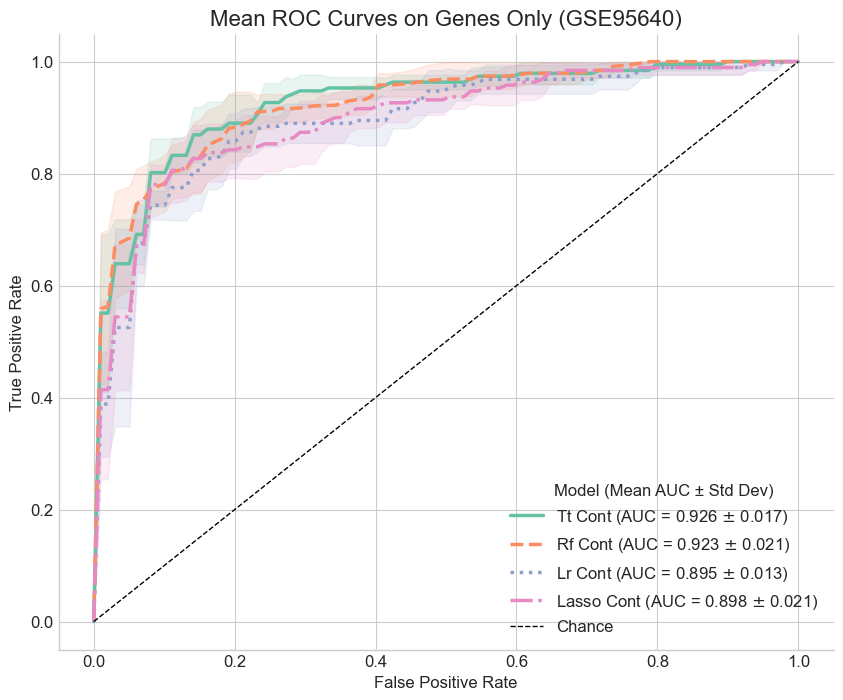


--- Generating Plot 2: Tab-Transformer Ablation Study (GSE95640) ---
Saved figure to: output\GSE95640_cv_roc_tt_internal.png


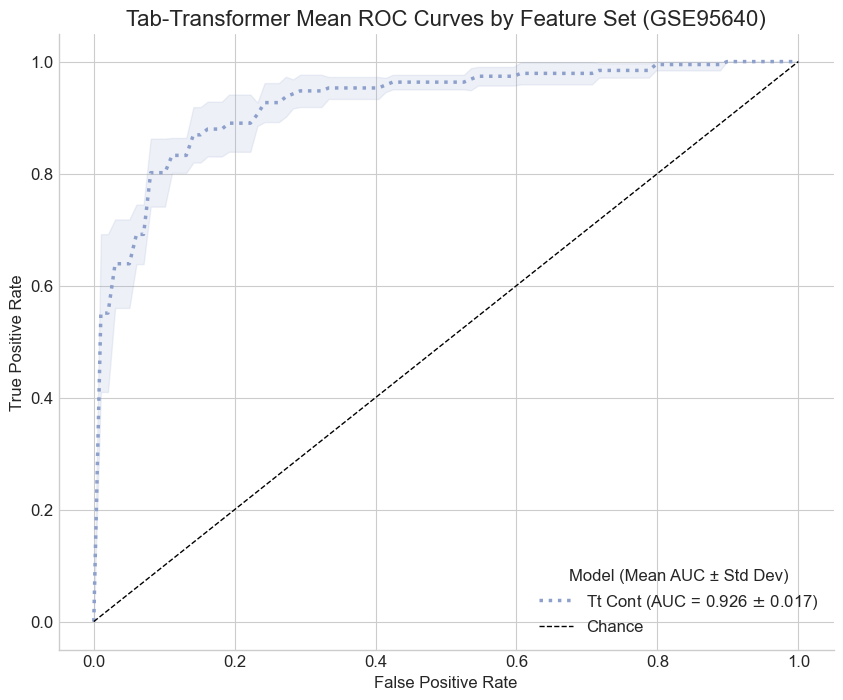


--- Generating Plot 3: Final Model Showdown on Combined Features (GSE95640) ---
No models to plot for 'Mean ROC Curves on Combined Features (GSE95640)'. Skipping figure.


In [5]:
# CELL 5: Generate Final Comparative Plots
def plot_mean_roc_curves_with_std(results_tprs, results_aucs, model_keys, title, save_path=None):
    """
    Helper function to plot multiple mean ROC curves from CV results,
    including a shaded standard deviation band for each curve.
    """
    plt.figure(figsize=(10, 8))
    colors = sns.color_palette('Set2', n_colors=len(model_keys))
    linestyles = ['-', '--', ':', '-.']
    
    # Track which keys actually have results
    plotted_keys = []

    # --- Loop through each model to plot ---
    for i, key in enumerate(model_keys):
        if key not in results_tprs or not results_tprs[key]:
            print(f"Warning: No results found for '{key}'. Skipping this curve.")
            continue
        
        plotted_keys.append(key)
        
        # --- Calculations for the current model ---
        tpr_array = np.array(results_tprs[key])
        mean_tprs = tpr_array.mean(axis=0)
        mean_tprs[-1] = 1.0  # Ensure the curve goes to the top-right corner

        mean_auc = auc(mean_fpr, mean_tprs)
        std_auc = np.std(results_aucs[key])

        std_tpr = tpr_array.std(axis=0)
        tprs_upper = np.minimum(mean_tprs + std_tpr, 1)
        tprs_lower = np.maximum(mean_tprs - std_tpr, 0)

        # --- Plotting for the current model ---
        label_text = f'{key.replace("_", " ").title()} (AUC = {mean_auc:.3f} $\\pm$ {std_auc:.3f})'
        plt.plot(mean_fpr, mean_tprs, color=colors[i], linestyle=linestyles[i % len(linestyles)], lw=2.5,
                 label=label_text)
        plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=colors[i], alpha=0.15)
    
    # --- Finalize the plot ---
    if not plotted_keys:
        print(f"No models to plot for '{title}'. Skipping figure.")
        plt.close() # Close the empty figure
        return

    plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', label='Chance')
    plt.title(title, fontsize=16)
    plt.xlabel('False Positive Rate');
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right", title="Model (Mean AUC ± Std Dev)");
    plt.grid(True);
    sns.despine()
    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
        print(f"Saved figure to: {save_path}")
    plt.show()


# 1. Update plot titles and save paths

# --- Plot 1: Continuous Features Only ---
print("\n--- Generating Plot 1: Mean ROC Curves on Continuous Features Only (GSE95640) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'],
    results['AUCs'],
    ['TT_cont', 'RF_cont', 'LR_cont', 'LASSO_cont'],
    "Mean ROC Curves on Genes Only (GSE95640)",
    save_path=OUT_DIR / "GSE95640_cv_roc_only_continuous.png"
)

# --- Plot 2: Tab-Transformer Ablation Study ---
print("\n--- Generating Plot 2: Tab-Transformer Ablation Study (GSE95640) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'],
    results['AUCs'],
    ['TT_comb', 'TT_cat', 'TT_cont'],
    "Tab-Transformer Mean ROC Curves by Feature Set (GSE95640)",
    save_path=OUT_DIR / "GSE95640_cv_roc_tt_internal.png"
)

# --- Plot 3: Combined Features Showdown ---
print("\n--- Generating Plot 3: Final Model Showdown on Combined Features (GSE95640) ---")
plot_mean_roc_curves_with_std(
    results['TPRs'],
    results['AUCs'],
    ['TT_comb', 'RF_comb', 'LR_comb', 'LASSO_comb'],
    "Mean ROC Curves on Combined Features (GSE95640)",
    save_path=OUT_DIR / "GSE95640_cv_roc_combined.png"
)